In [1]:
import pandas as pd

In [2]:
data = pd.read_csv(r"C:\Users\lenovo\OneDrive\Desktop\Folder\daily-python-data-lab\04_machine_learning\Classification\train (2).csv")

In [3]:
data.columns

Index(['id', 'perc_premium_paid_by_cash_credit', 'age_in_days', 'Income',
       'Count_3-6_months_late', 'Count_6-12_months_late',
       'Count_more_than_12_months_late', 'application_underwriting_score',
       'no_of_premiums_paid', 'sourcing_channel', 'residence_area_type',
       'premium', 'renewal'],
      dtype='object')

In [4]:
data['sourcing_channel'].unique()

array(['A', 'B', 'C', 'D', 'E'], dtype=object)

In [5]:
data.head()

,id,perc_premium_paid_by_cash_credit,age_in_days,Income,Count_3-6_months_late,Count_6-12_months_late,Count_more_than_12_months_late,application_underwriting_score,no_of_premiums_paid,sourcing_channel,residence_area_type,premium,renewal
0,66633,0.086,16805,114110,0.0,0.0,0.0,99.87,8,A,Urban,3300,1
1,62807,0.010,22638,315120,0.0,0.0,0.0,99.25,19,A,Rural,3300,1
2,30822,0.312,11685,125100,0.0,0.0,0.0,98.84,13,A,Urban,7500,1
3,101201,0.276,24829,150200,2.0,0.0,0.0,99.02,17,A,Urban,7500,1
4,63479,0.308,20445,137880,0.0,0.0,0.0,98.80,11,A,Rural,7500,1


In [6]:
data.isna().sum()

id                                     0
perc_premium_paid_by_cash_credit       0
age_in_days                            0
Income                                 0
Count_3-6_months_late                 88
Count_6-12_months_late                88
Count_more_than_12_months_late        88
application_underwriting_score      2539
no_of_premiums_paid                    0
sourcing_channel                       0
residence_area_type                    0
premium                                0
renewal                                0
dtype: int64

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

<Axes: xlabel='application_underwriting_score', ylabel='Count'>

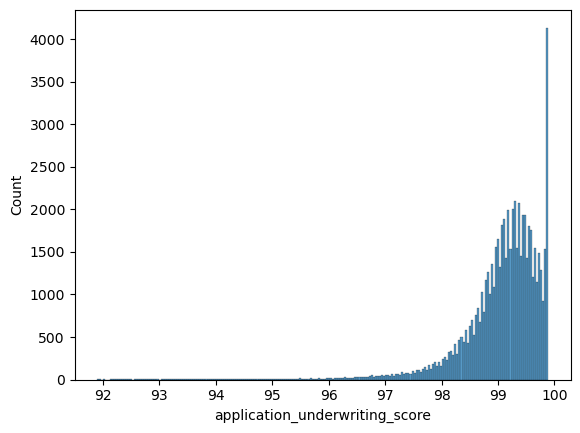

In [8]:
sns.histplot(data=data["application_underwriting_score"])

In [9]:
data.shape

(67875, 13)

In [10]:
data["Count_3-6_months_late"].value_counts()

Count_3-6_months_late
0.0     56731
1.0      7534
2.0      2128
3.0       829
4.0       323
5.0       145
6.0        59
7.0        20
8.0        12
9.0         3
12.0        1
13.0        1
10.0        1
Name: count, dtype: int64

In [11]:
from sklearn.impute import SimpleImputer

In [12]:
si = SimpleImputer(strategy='median')

In [13]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67875 entries, 0 to 67874
Data columns (total 13 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   id                                67875 non-null  int64  
 1   perc_premium_paid_by_cash_credit  67875 non-null  float64
 2   age_in_days                       67875 non-null  int64  
 3   Income                            67875 non-null  int64  
 4   Count_3-6_months_late             67787 non-null  float64
 5   Count_6-12_months_late            67787 non-null  float64
 6   Count_more_than_12_months_late    67787 non-null  float64
 7   application_underwriting_score    65336 non-null  float64
 8   no_of_premiums_paid               67875 non-null  int64  
 9   sourcing_channel                  67875 non-null  object 
 10  residence_area_type               67875 non-null  object 
 11  premium                           67875 non-null  int64  
 12  rene

In [14]:
num_col = list(data.select_dtypes(include = "number").columns)
num_col = ['perc_premium_paid_by_cash_credit',
 'age_in_days',
 'Income',
 'Count_3-6_months_late',
 'Count_6-12_months_late',
 'Count_more_than_12_months_late',
 'application_underwriting_score',
 'no_of_premiums_paid',
 'premium']

In [15]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [ ]:
data[num_col] = si.fit_transform(data[num_col])

In [ ]:
data.isna().sum().sum() == 0

In [ ]:
data

In [40]:
from sklearn.preprocessing import OneHotEncoder

In [ ]:
OHE = OneHotEncoder(sparse_output=False)

In [ ]:
residence_area_encoded = OHE.fit_transform(data[["residence_area_type"]])

In [ ]:
residence_area_encoded

In [ ]:
data[["Urban", "Rural"]] = residence_area_encoded

In [ ]:
data = data.rename(columns = {"Urban":"Rural","Rural":"Urban"})

In [ ]:
data

In [ ]:
from sklearn.preprocessing import TargetEncoder

In [ ]:
te = TargetEncoder()

In [ ]:
data["sourcing_channel_encoded"] = te.fit_transform(data[["sourcing_channel"]], data["renewal"])

In [ ]:
data

In [ ]:
data.columns

In [ ]:
data[ ['perc_premium_paid_by_cash_credit', 'age_in_days', 'Income',
       'Count_3-6_months_late', 'Count_6-12_months_late',
       'Count_more_than_12_months_late', 'application_underwriting_score',
       'no_of_premiums_paid', 
       'premium',  'Rural', 'Urban', 'sourcing_channel_encoded', 'renewal']]

In [ ]:
sns.heatmap(data[ ['perc_premium_paid_by_cash_credit', 'age_in_days', 'Income',
       'Count_3-6_months_late', 'Count_6-12_months_late',
       'Count_more_than_12_months_late', 'application_underwriting_score',
       'no_of_premiums_paid', 
       'premium',  'Rural', 'Urban', 'sourcing_channel_encoded', 'renewal']].corr(),fmt='.2f',  annot=True)

In [ ]:
data["Total_late"] =data['Count_3-6_months_late']+data['Count_6-12_months_late']+data['Count_more_than_12_months_late']

In [ ]:
data["Total_late"].value_counts()

In [ ]:
data[['perc_premium_paid_by_cash_credit', 'age_in_days', 'Income',
       'Total_late', 'application_underwriting_score',
       'no_of_premiums_paid', 
       'premium',  'Rural', 'Urban', 'sourcing_channel_encoded', 'renewal']]

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
sd = StandardScaler()

In [ ]:
data[['perc_premium_paid_by_cash_credit', 'age_in_days', 'Income',
       'Total_late', 'application_underwriting_score',
       'no_of_premiums_paid', 
       'premium',  'sourcing_channel_encoded']] = sd.fit_transform(data[['perc_premium_paid_by_cash_credit', 'age_in_days', 'Income',
       'Total_late', 'application_underwriting_score',
       'no_of_premiums_paid', 
       'premium',  'sourcing_channel_encoded']])

In [ ]:
final_data = data[['perc_premium_paid_by_cash_credit', 'age_in_days', 'Income',
       'Total_late', 'application_underwriting_score',
       'no_of_premiums_paid', 
       'premium',  'Rural', 'Urban', 'sourcing_channel_encoded', 'renewal']]

In [ ]:
## target encoding, model selection, model training, incentive ..

## Data _read
 SimpleImputer
 Total_late
 OHE
 Target_Encoding 
 StanderScaler
 train_test_split


 ## model
 Random_forest
 Xgboost

In [ ]:
from sklearn.model_selection import train_test_split

In [17]:
X = final_data.drop(columns="renewal")
y = final_data["renewal"]

NameError: name 'final_data' is not defined

In [18]:
X_train,X_test,y_train,y_test =  train_test_split(X,y,test_size= 0.2, random_state=42)

NameError: name 'train_test_split' is not defined

In [19]:
from sklearn.ensemble import RandomForestClassifier

In [20]:
rf = RandomForestClassifier(max_depth=5)

In [21]:
rf.fit(X_train,y_train)

NameError: name 'X_train' is not defined

In [22]:
from sklearn.metrics import (
confusion_matrix,
classification_report,
accuracy_score
)

In [23]:
rf_pred = rf.predict(X_test)

NameError: name 'X_test' is not defined

In [24]:
print(classification_report(y_test,rf_pred))

NameError: name 'y_test' is not defined

In [25]:
accuracy_score(y_test,rf_pred)

NameError: name 'y_test' is not defined

In [26]:
rf_train_pred = rf.predict(X_train)

NameError: name 'X_train' is not defined

In [27]:
accuracy_score(y_train, rf_train_pred)

NameError: name 'y_train' is not defined

In [28]:
# import xgboost as xgb
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import accuracy_score
# import pandas as pd
import numpy as np

In [29]:
from xgboost import XGBClassifier

In [30]:
XGB = XGBClassifier

In [31]:
XGB.fit(X_train,y_train)

NameError: name 'X_train' is not defined

In [32]:
np.array(final_data)

NameError: name 'final_data' is not defined

In [33]:
pip install xgboost==2.1.4

Note: you may need to restart the kernel to use updated packages.


In [34]:
import xgboost

In [35]:
xgboost.__version__
XGBClassifier(max_depth=1,max_leaves=1)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [36]:
class XGB_classification():
    def __init__(self):
        self.xgbmodel = XGBClassifier(max_depth=1,max_leaves=1,)

    def train_model(self,x,y):
        self.xgbmodel.fit(x,y)

    def prediction(self,x):
        return self.xgbmodel.predict(x)

In [37]:
xgb_mod = XGB_classification()

In [38]:
xgb_mod.train_model(X_train,y_train)

NameError: name 'X_train' is not defined

In [ ]:
y_pred=xgb_mod.prediction(X_test)

In [ ]:
y_t_pred=xgb_mod.prediction(X_train)

In [ ]:
type(y_pred)

In [ ]:
accuracy_score(y_test, y_pred)

In [ ]:
print(classification_report(y_test,y_pred))

In [ ]:
accuracy_score(y_train, y_t_pred)

In [48]:
data_process = ColumnTransformer(
    transformers= [
        ("MissingImputer",SimpleImputer(strategy="median"),num_col),
        ("OHE",OneHotEncoder(sparse_output=False),["residence_area_type"]),
        ("Scaling",StandardScaler(),num_col)
    ]
    
)

In [52]:
data_process = ColumnTransformer(
    transformers= [
        ("OHE",OneHotEncoder(sparse_output=False),["residence_area_type"]),
        ("TargetEncoder",TargetEncoder(),["sourcing_channel"]),
        ("Standard",StandardScaler(),['perc_premium_paid_by_cash_credit', 'age_in_days', 'Income',
       'Total_late', 'application_underwriting_score',
       'no_of_premiums_paid', 
       'premium'])
    ]
    
)

NameError: name 'TargetEncoder' is not defined

In [51]:
X=data_process.fit_transform(data[['perc_premium_paid_by_cash_credit',
 'age_in_days',
 'Income',
 'Count_3-6_months_late',
 'Count_6-12_months_late',
 'Count_more_than_12_months_late',
 'application_underwriting_score',
 'no_of_premiums_paid',
 'premium',
'residence_area_type']])
X

array([[0., 1.],
       [1., 0.],
       [0., 1.],
       ...,
       [0., 1.],
       [0., 1.],
       [1., 0.]], shape=(67875, 2))

In [54]:
target_encode = Pipeline[("Target",TargetEncoder()),
                ("StandardScacler".StandardScaler())]

NameError: name 'TargetEncoder' is not defined